In [5]:
#Install Dependencies
!pip install langchain-openai
!pip install langchain_community
!pip install langchain_chroma

In [7]:
# Langchain and other imports

from __future__ import annotations

import os
import zipfile
from typing import List, TypedDict

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage

from langgraph.graph import StateGraph, END

In [8]:
import os
import openai

from google.colab import userdata

# Retrieve OpenAI API key from Colab secrets
Simon_GBA_479_Class = userdata.get('Simon_GBA_479_Class')


# Initialize the OpenAI client
client = openai.OpenAI(api_key=Simon_GBA_479_Class)

In [15]:
#Unzip Northbridge PDFs

ZIP_PATH = "/content/Northbridge_Support_Manuals.zip"   # Corrected path
# In standard Colab, you might use: ZIP_PATH = "/content/Northbridge_Support_Manuals.zip"

EXTRACT_DIR = "/content/northbridge_pdfs"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extracted files:")
for root, _, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith(".pdf"):
            print("-", os.path.join(root, f))

Extracted files:
- /content/northbridge_pdfs/Northbridge_Evaluation.pdf
- /content/northbridge_pdfs/Northbridge_Content_Standards.pdf
- /content/northbridge_pdfs/Northbridge_Food_Access_Internal_FAQ.pdf
- /content/northbridge_pdfs/Northbridge_Policy_Brief_Volunteers.pdf
- /content/northbridge_pdfs/Northbridge_Volunteer_Onboarding_and_Coordination_Manual.pdf
- /content/northbridge_pdfs/Northbridge_Advocacy_FAQ.pdf
- /content/northbridge_pdfs/Northbridge_Policy_Brief_Food.pdf
- /content/northbridge_pdfs/Northbridge_Strategic_Plan.pdf


In [36]:
import os
from langchain_community.document_loaders import PyPDFLoader

print(f"Displaying the first page content of each PDF in '{EXTRACT_DIR}':\n")

for root, _, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith(".pdf"):
            file_path = os.path.join(root, f)
            loader = PyPDFLoader(file_path)
            pages = loader.load()

            if pages:
                # Display the content of the first page
                first_page_content = pages[0].page_content
                print(f"--- {os.path.basename(file_path)} (Page 1) ---")
                print(first_page_content[:1000]) # Print first 1000 characters
                print("\n... (truncated)\n")
            else:
                print(f"--- {os.path.basename(file_path)} (No content on first page) ---")
            print("\n" + "="*80 + "\n")


Displaying the first page content of each PDF in '/content/northbridge_pdfs':

--- Northbridge_Evaluation.pdf (Page 1) ---
Northbridge Community Alliance 
2025 Program Evaluation Summary 
Published: January 2026 
 
Overview 
This summary presents key findings from Northbridge’s 2025 program evaluation cycle. 
The evaluation includes participation data, survey feedback, and selected outcome 
indicators across Food Access, Tutoring & Youth Support, and Volunteer Engagement 
programs. 
 
The purpose of this evaluation is to inform internal learning, strengthen program 
design, and support evidence-informed advocacy. Findings reflect documented 
program data and participant feedback collected during the 2025 calendar year.

... (truncated)



--- Northbridge_Content_Standards.pdf (Page 1) ---
Northbridge Community Alliance 
Content Integrity & Citation Standard 
Effective: January 2026 
 
Purpose 
Northbridge Community Alliance is committed to ensuring that all advocacy 
materials, briefin

In [24]:
 # Build vectorstore (PDF → chunks → embeddings → Chroma)
def build_vectorstore() -> Chroma:
    # Loads all PDFs; PyPDFLoader includes metadata like {"source": path, "page": n}
    docs = DirectoryLoader(
        EXTRACT_DIR,
        glob="**/*.pdf",
        loader_cls=PyPDFLoader
    ).load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=900,
        chunk_overlap=150,
        separators=["\n\n", "\n", " ", ""],
    )
    splits = splitter.split_documents(docs)

    embeddings = OpenAIEmbeddings(openai_api_key=Simon_GBA_479_Class)
    vectorstore = Chroma.from_documents(splits, embedding=embeddings)
    return vectorstore


def retrieve_with_scores(vectorstore: Chroma, query: str, k: int = 5):
    """
    Returns (docs, best_score). Higher score => better semantic match.
    """
    results = vectorstore.similarity_search_with_relevance_scores(query, k=k)
    if not results:
        return [], 0.0
    docs = [doc for doc, _ in results]
    best = max(score for _, score in results)
    return docs, float(best)


def format_docs_with_citations(docs: List[Document], max_chars_per_doc: int = 1800) -> str:
    """
    Formats context for the LLM and preserves source+page citations.
    """
    blocks = []
    for d in docs:
        src = d.metadata.get("source", "unknown_source")
        page = d.metadata.get("page", None)
        page_str = f"{page+1}" if isinstance(page, int) else "?"
        filename = os.path.basename(src)

        text = (d.page_content or "").strip()
        if len(text) > max_chars_per_doc:
            text = text[:max_chars_per_doc].rstrip() + "…"

        blocks.append(
            f"[SOURCE: {filename} | page {page_str}]\n{text}"
        )
    return "\n\n---\n\n".join(blocks)

In [20]:
# Prompts (Grounded RAG + Safe Fallback)

llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0, openai_api_key=Simon_GBA_479_Class)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are Northbridge’s Advocacy & Policy Policy Content & Briefing Assistant.\n"
     "You must answer stakeholder questions using ONLY the provided context from Northbridge PDFs.\n"
     "Requirements:\n"
     "1) Be accurate, mission-consistent, and evidence-based.\n"
     "2) If the answer is not supported in the context, say: "
     "\"I don’t know based on the available Northbridge documents I have.\" (exactly)\n"
     "3) When you make a claim, include citations in-line like: (Northbridge_Strategic_Plan.pdf p. 12)\n"
     "4) Prefer a short briefing format: 3–6 bullet points max, then a 1–2 sentence summary.\n\n"
     "Context:\n{context}"
    ),
    MessagesPlaceholder("chat_history"),
    ("user", "{question}"),
])

fallback_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a helpful assistant for Northbridge Advocacy & Community Issues.\n"
     "Retrieval confidence is low OR the documents do not support an answer.\n"
     "Rules:\n"
     "1) Do NOT claim anything is in Northbridge documents.\n"
     "2) Say you couldn't find enough in the available knowledge base.\n"
     "3) Ask ONE clarifying question.\n"
     "4) Provide 2–3 next steps (what to search for / what doc type to consult / what detail to provide).\n"
     "Be concise."
    ),
    MessagesPlaceholder("chat_history"),
    ("user", "User question: {question}\nRetrieval score: {score:.2f}"),
])

In [21]:
# LangGraph state + nodes
class GraphState(TypedDict, total=False):
    messages: List[AnyMessage]
    chat_history: List[AnyMessage]
    question: str

    retrieved_docs: List[Document]
    context: str
    retrieval_score: float

    answer: str


def last_user_question(state: GraphState) -> str:
    if "question" in state and state["question"]:
        return state["question"]
    for m in reversed(state.get("messages", [])):
        if isinstance(m, HumanMessage):
            return m.content
    return ""


def node_retrieve(state: GraphState) -> GraphState:
    # Cache vectorstore so embeddings aren't rebuilt each turn
    if not hasattr(node_retrieve, "_vs"):
        node_retrieve._vs = build_vectorstore()

    vs: Chroma = node_retrieve._vs
    q = last_user_question(state)

    docs, score = retrieve_with_scores(vs, q, k=5)
    context = format_docs_with_citations(docs)

    return {
        "question": q,
        "retrieved_docs": docs,
        "context": context,
        "retrieval_score": score,
    }


def node_answer_rag(state: GraphState) -> GraphState:
    q = state["question"]
    context = state.get("context", "")
    chat_history = state.get("chat_history", [])

    chain = rag_prompt | llm | StrOutputParser()
    answer = chain.invoke({
        "question": q,
        "context": context,
        "chat_history": chat_history,
    })

    new_history = chat_history + [HumanMessage(content=q), AIMessage(content=answer)]
    msgs = state.get("messages", [])
    msgs.append(AIMessage(content=answer))

    return {"answer": answer, "chat_history": new_history, "messages": msgs}


def node_fallback(state: GraphState) -> GraphState:
    q = state["question"]
    score = state.get("retrieval_score", 0.0)
    chat_history = state.get("chat_history", [])

    chain = fallback_prompt | llm | StrOutputParser()
    answer = chain.invoke({
        "question": q,
        "score": score,
        "chat_history": chat_history,
    })

    new_history = chat_history + [HumanMessage(content=q), AIMessage(content=answer)]
    msgs = state.get("messages", [])
    msgs.append(AIMessage(content=answer))

    return {"answer": answer, "chat_history": new_history, "messages": msgs}


def route_on_answer(state: GraphState) -> str:
    """
    Same idea as the 5_3 file: if model says it doesn't know, fall back.
    Also add a retrieval-score guardrail to reduce risky answers.
    """
    answer = (state.get("answer", "") or "").strip().lower()
    score = float(state.get("retrieval_score", 0.0))

    # Guardrail 1: explicit "don't know" phrase
    if answer == "i don’t know based on the available northbridge documents i have.":
        return "fallback"

    # Guardrail 2: low retrieval confidence (tune as needed)
    if score < 0.40:
        return "fallback"

    return "end"


In [22]:
# Build graph (retrieve → answer_rag → conditional fallback)
def build_graph():
    g = StateGraph(GraphState)

    g.add_node("retrieve", node_retrieve)
    g.add_node("answer_rag", node_answer_rag)
    g.add_node("fallback", node_fallback)

    g.set_entry_point("retrieve")
    g.add_edge("retrieve", "answer_rag")

    g.add_conditional_edges(
        "answer_rag",
        route_on_answer,
        {"fallback": "fallback", "end": END},
    )
    g.add_edge("fallback", END)

    return g.compile()

app = build_graph()


In [25]:
# Ask function + quick test
def ask(question: str) -> str:
    state: GraphState = {
        "messages": [SystemMessage(content="Northbridge Policy Content & Briefing Assistant running.")],
        "chat_history": [],
        "question": question,
    }
    out = app.invoke(state)
    return out.get("answer", "")

print(ask("What are Northbridge’s stated priorities related to food access? Please cite the documents."))


- Northbridge’s priorities related to food access include increasing food affordability, improving supply chain reliability, and reducing geographic disparities in access to nutritious food (Northbridge_Strategic_Plan.pdf p. 2).  
- The organization aims to expand access to nutritious food through partnerships, direct service programs, and policy engagement that address structural barriers (Northbridge_Strategic_Plan.pdf p. 2).  
- Northbridge supports municipal efforts to strengthen local food retail development, transportation coordination, and referral partnerships (Northbridge_Advocacy_FAQ.pdf p. 1).  
- The organization emphasizes culturally responsive food distribution options, multilingual communication, and clear eligibility information (Northbridge_Policy_Brief_Food.pdf p. 3).  

In summary, Northbridge’s food access priorities focus on affordability, supply reliability, reducing disparities, and culturally responsive service delivery.


In [26]:
# interactive chat loop
def chat():
    state: GraphState = {
        "messages": [SystemMessage(content="Northbridge Policy Content & Briefing Assistant running.")],
        "chat_history": [],
    }
    print("Ask questions about Northbridge advocacy/policy materials. Type 'exit' to quit.")
    while True:
        q = input("\nYou: ").strip()
        if q.lower() in {"exit", "quit"}:
            break
        state["question"] = q
        state = app.invoke(state)
        print("\nAssistant:\n", state.get("answer",""))


In [28]:
chat()

Ask questions about Northbridge advocacy/policy materials. Type 'exit' to quit.

You: What is Northbridge policy on immigration matters?

Assistant:
 - Northbridge does not take formal positions on national immigration legislation (Northbridge_Advocacy_FAQ.pdf p. 2).
- The organization’s advocacy efforts focus on documented local community needs aligned with its Strategic Plan (Northbridge_Advocacy_FAQ.pdf p. 2).
- Its primary focus is on local community issues rather than national immigration policy.

In summary, Northbridge does not have a formal policy position on immigration matters, concentrating instead on local community needs.

You: What is Northbridge policy on donation intakes?

Assistant:
 Could you clarify whether you're asking about the types of donations accepted, the process for making donations, or the guidelines for donation eligibility? 

Next steps:
1. Review Northbridge's donation or fundraising policy documents.
2. Check for any publicly available donation guidelin

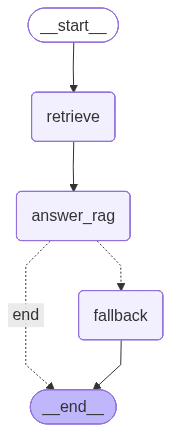

In [29]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))